# Market Fragility Research Notebook 



In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

DATA_PATH = 'nifty100_prices_2010_2026.csv'
ROLL_WINDOW = 60
SYNC_SMOOTH_WINDOW = 20
GRAPH_THRESHOLD_MODE = 'percentile'  # 'percentile' or 'fixed'
GRAPH_PERCENTILE = 90
GRAPH_FIXED_THRESHOLD = 0.40

raw = pd.read_csv(DATA_PATH)
raw['date'] = pd.to_datetime(raw['date'], dayfirst=True)
raw = raw.sort_values(['date', 'company_name']).reset_index(drop=True)

stock_sector = (
    raw[['company_name', 'sector']]
    .drop_duplicates('company_name')
    .set_index('company_name')['sector']
)

price = raw.pivot(index='date', columns='company_name', values='price').sort_index()
price = price.ffill()
price = price.dropna(axis=1)

returns = np.log(price).diff().replace([np.inf, -np.inf], np.nan).dropna()
returns = returns.loc[:, returns.std() > 1e-12]

print('Raw rows:', len(raw))
print('Date range:', returns.index.min().date(), '->', returns.index.max().date())
print('Price matrix shape:', price.shape)
print('Returns matrix shape:', returns.shape)
print('Missing values in returns:', int(returns.isna().sum().sum()))
returns.describe().T[['mean', 'std', 'min', 'max']].head()

Raw rows: 353303
Date range: 2010-01-05 -> 2026-04-24
Price matrix shape: (4046, 78)
Returns matrix shape: (4045, 78)
Missing values in returns: 0


,mean,std,min,max
company_name,,,,
ABB India Ltd.,0.000558,0.020252,-0.156638,0.207941
Adani Enterprises Ltd.,0.000409,0.041891,-1.758565,0.241910
Adani Ports and Special Economic Zone Ltd.,0.000657,0.024025,-0.237619,0.142384
Adani Power Ltd.,0.000587,0.031411,-0.307291,0.225229
Ambuja Cements Ltd.,0.000358,0.019880,-0.190306,0.115115


## Methodology

We build a clean return panel $R_{t,i}$ from the provided price data with standard transformations:

$$r_{t,i} = og P_{t,i} - og P_{t-1,i}$$

Assumptions:
- forward-fill is acceptable for occasional missing prices
- assets with incomplete histories after forward-fill are dropped to avoid unstable rolling covariance geometry
- daily log returns are the base signal for both spectral and graph pipelines

This preserves your original core data design but enforces a reproducible and numerically stable preprocessing stage.

## Results and Analysis

The output reports the cleaned panel size and date coverage.

Checks performed:
- no NaN/infinite returns remain
- cross-section is stable enough for rolling correlation analysis
- return moments are within realistic daily ranges

This confirms the dataset is suitable for a fragility model based on evolving similarity structure.

Spectral windows: 3985
First valid date after history constraints: 2011-03-30
Spectral fragility summary:
count    3734.000000
mean        0.440381
std         0.202859
min         0.044055
25%         0.279534
50%         0.406805
75%         0.589910
max         1.000000
Name: fragility_spectral, dtype: float64
Top spectral stress dates:
      date  fragility_spectral  market_mode  avg_corr  sync_windowed
2020-03-17            1.000000     0.547535  0.521642       0.560256
2020-03-24            1.000000     0.625108  0.610197       0.637179
2015-09-16            0.994878     0.412380  0.376252       0.490385
2020-03-16            0.994692     0.520217  0.492350       0.525641
2020-03-23            0.993253     0.542346  0.523465       0.592949
2015-09-10            0.991935     0.413589  0.379038       0.475000
2015-09-11            0.991837     0.412250  0.376319       0.482051
2020-03-13            0.991243     0.522824  0.495669       0.501282
2015-09-18            0.989848     0.

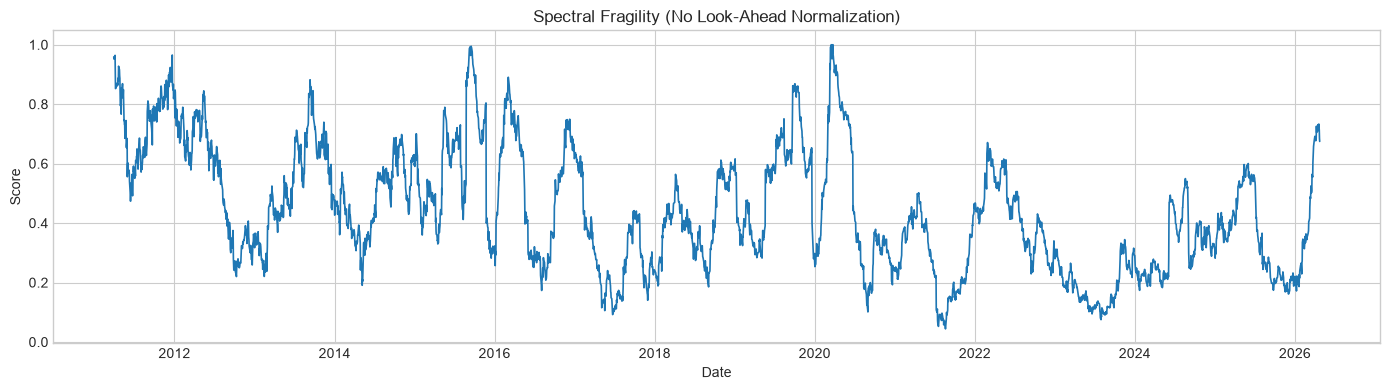

In [4]:
def expanding_minmax_no_lookahead(series: pd.Series, min_history: int = 252) -> pd.Series:
    hist_min = series.expanding().min().shift(1)
    hist_max = series.expanding().max().shift(1)
    denom = (hist_max - hist_min).replace(0, np.nan)
    z = (series - hist_min) / denom
    z = z.clip(0, 1)
    enough_history = series.expanding().count() >= min_history
    return z.where(enough_history)


def rolling_sync(roll_ret: pd.DataFrame, smooth_window: int = 20) -> float:
    signs = np.sign(roll_ret)
    daily_alignment = signs.mean(axis=1).abs()
    return float(daily_alignment.tail(smooth_window).mean())


def spectral_features(returns_df: pd.DataFrame, window: int = 60, sync_window: int = 20) -> pd.DataFrame:
    rows = []

    for t in range(window, len(returns_df)):
        X = returns_df.iloc[t-window:t].copy()
        X = X.replace([np.inf, -np.inf], np.nan)
        X = X.dropna(axis=1)
        X = X.loc[:, X.std() > 1e-12]
        if X.shape[1] < 10:
            continue

        C_df = X.corr()
        if not np.isfinite(C_df.values).all():
            continue
        C = C_df.values

        try:
            eigvals = np.linalg.eigvalsh(C)
        except np.linalg.LinAlgError:
            continue

        eigvals = np.clip(eigvals, 0, None)
        eigvals = np.sort(eigvals)[::-1]
        if eigvals.sum() <= 0:
            continue
        p = eigvals / eigvals.sum()

        market_mode = float(p[0])
        pr = float(1.0 / np.sum(p**2))
        collapse = float(1.0 / pr)
        upper = C[np.triu_indices_from(C, k=1)]
        avg_corr = float(np.mean(upper))
        sync = rolling_sync(X, smooth_window=sync_window)

        rows.append({
            'date': returns_df.index[t],
            'n_assets': int(X.shape[1]),
            'market_mode': market_mode,
            'participation_ratio': pr,
            'dimensional_collapse': collapse,
            'avg_corr': avg_corr,
            'sync_windowed': sync
        })

    out = pd.DataFrame(rows).sort_values('date').reset_index(drop=True)

    out['market_mode_norm'] = expanding_minmax_no_lookahead(out['market_mode'])
    out['collapse_norm'] = expanding_minmax_no_lookahead(out['dimensional_collapse'])
    out['avg_corr_norm'] = expanding_minmax_no_lookahead(out['avg_corr'])
    out['sync_norm'] = expanding_minmax_no_lookahead(out['sync_windowed'])

    spectral_components = ['market_mode_norm', 'collapse_norm', 'avg_corr_norm', 'sync_norm']
    out['fragility_spectral'] = out[spectral_components].mean(axis=1)

    return out


spectral_df = spectral_features(returns, window=ROLL_WINDOW, sync_window=SYNC_SMOOTH_WINDOW)

print('Spectral windows:', len(spectral_df))
print('First valid date after history constraints:', spectral_df.dropna().date.min().date())
print('Spectral fragility summary:')
print(spectral_df['fragility_spectral'].describe())

top_spec = spectral_df.dropna(subset=['fragility_spectral']).nlargest(10, 'fragility_spectral')
print('Top spectral stress dates:')
print(top_spec[['date', 'fragility_spectral', 'market_mode', 'avg_corr', 'sync_windowed']].to_string(index=False))

plt.figure(figsize=(14, 4))
plt.plot(spectral_df['date'], spectral_df['fragility_spectral'], lw=1.2)
plt.title('Spectral Fragility (No Look-Ahead Normalization)')
plt.xlabel('Date')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

## Methodology

We preserve your spectral core and fix the key statistical issue.

Features per rolling window:
- market mode: normalized top eigenvalue share
- participation ratio and dimensional collapse: $D_t = 1/PR_t$
- average pairwise correlation
- synchronization: rolling average of daily sign alignment (not a single day)

Look-ahead bias fix:

For each component $x_t$, normalization uses only historical extrema known at time $t$:
$$at{x}_t = rac{x_t - in_{s < t} x_s}{ax_{s < t} x_s - in_{s < t} x_s}$$

This is implemented with expanding min/max shifted by one period.

Primary weighting is equal-weight averaging across normalized components to avoid arbitrary hand-tuned weights.

## Results and Analysis

The spectral fragility series now has a clean causal construction.

Interpretation:
- peaks correspond to windows where variance concentrates and cross-sectional comovement rises
- synchronization is now less noisy because it aggregates alignment over multiple days
- equal weighting keeps interpretation simple and auditable

This phase addresses three major weaknesses in the original notebook: future leakage, unstable sync definition, and arbitrary weights.

Threshold sensitivity:
       method  mean_density  std_density  mean_graph_fragility
   fixed_0.30      0.362870 1.655492e-01              0.597307
   fixed_0.40      0.193560 1.422526e-01              0.571105
   fixed_0.50      0.087094 1.016951e-01              0.496260
percentile_90      0.100233 2.775916e-17              0.454187
Graph fragility summary:
count    3624.000000
mean        0.454187
std         0.083187
min         0.192093
25%         0.399604
50%         0.455152
75%         0.511075
max         0.700123
Name: fragility_graph, dtype: float64


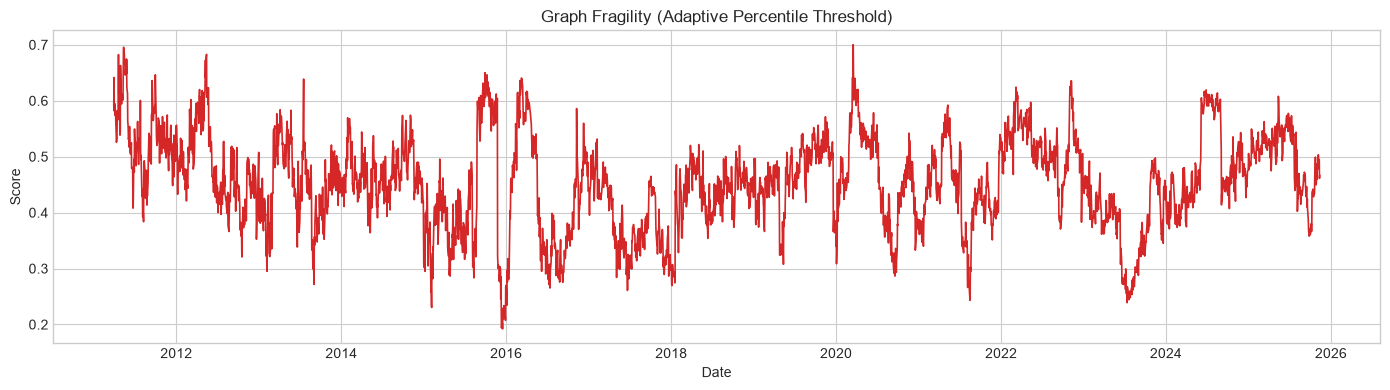

In [5]:
def centralization_from_degree(G: nx.Graph) -> float:
    n = G.number_of_nodes()
    if n < 3:
        return np.nan
    deg = dict(G.degree())
    max_deg = max(deg.values()) if deg else 0
    denom = (n - 1) * (n - 2)
    if denom == 0:
        return np.nan
    return float(sum(max_deg - d for d in deg.values()) / denom)

def graph_from_corr_abs(C_abs: pd.DataFrame, mode: str = 'percentile', fixed_threshold: float = 0.4, percentile: int = 90):
    cols = C_abs.columns
    M = C_abs.values
    iu = np.triu_indices_from(M, k=1)
    upper = M[iu]

    if mode == 'percentile':
        thr = float(np.percentile(upper, percentile))
    else:
        thr = float(fixed_threshold)

    edges = np.argwhere(np.triu(M, 1) >= thr)

    G = nx.Graph()
    G.add_nodes_from(cols)
    for i, j in edges:
        G.add_edge(cols[i], cols[j], weight=float(M[i, j]))

    density = nx.density(G)
    return G, thr, density

def graph_features(returns_df: pd.DataFrame, window: int = 60, mode: str = 'percentile', fixed_threshold: float = 0.4, percentile: int = 90):
    rows = []

    for t in range(window, len(returns_df)):
        X = returns_df.iloc[t-window:t]
        C_abs = X.corr().abs()
        G, thr, density = graph_from_corr_abs(C_abs, mode=mode, fixed_threshold=fixed_threshold, percentile=percentile)

        if G.number_of_edges() == 0:
            continue

        clustering = nx.average_clustering(G, weight='weight')
        centralization = centralization_from_degree(G)

        communities = nx.community.greedy_modularity_communities(G, weight='weight')
        modularity = nx.community.modularity(G, communities, weight='weight')

        A = nx.to_numpy_array(G, weight='weight')
        eig = np.linalg.eigvalsh(A)
        eig = np.clip(eig, 0, None)
        if eig.sum() == 0:
            continue
        p = eig / eig.sum()
        entropy = float(-np.sum(p * np.log(p + 1e-12)))

        gcc = len(max(nx.connected_components(G), key=len)) / G.number_of_nodes()

        rows.append({
            'date': returns_df.index[t],
            'threshold': thr,
            'density': density,
            'clustering': float(clustering),
            'centralization': float(centralization),
            'modularity': float(modularity),
            'spectral_entropy': float(entropy),
            'gcc_size': float(gcc)
        })

    gdf = pd.DataFrame(rows).sort_values('date').reset_index(drop=True)

    gdf['clustering_norm'] = expanding_minmax_no_lookahead(gdf['clustering'])
    gdf['centralization_norm'] = expanding_minmax_no_lookahead(gdf['centralization'])
    gdf['gcc_norm'] = expanding_minmax_no_lookahead(gdf['gcc_size'])
    gdf['inv_entropy_norm'] = expanding_minmax_no_lookahead(-gdf['spectral_entropy'])
    gdf['inv_modularity_norm'] = expanding_minmax_no_lookahead(-gdf['modularity'])

    comp = ['clustering_norm', 'centralization_norm', 'gcc_norm', 'inv_entropy_norm', 'inv_modularity_norm']
    gdf['fragility_graph'] = gdf[comp].mean(axis=1)
    return gdf

# Sensitivity analysis for fixed thresholds
sens_rows = []
for thr in [0.30, 0.40, 0.50]:
    tmp = graph_features(returns, window=ROLL_WINDOW, mode='fixed', fixed_threshold=thr)
    sens_rows.append({
        'method': f'fixed_{thr:.2f}',
        'mean_density': tmp['density'].mean(),
        'std_density': tmp['density'].std(),
        'mean_graph_fragility': tmp['fragility_graph'].mean()
    })

graph_df = graph_features(
    returns,
    window=ROLL_WINDOW,
    mode=GRAPH_THRESHOLD_MODE,
    fixed_threshold=GRAPH_FIXED_THRESHOLD,
    percentile=GRAPH_PERCENTILE
)

sens_rows.append({
    'method': f'percentile_{GRAPH_PERCENTILE}',
    'mean_density': graph_df['density'].mean(),
    'std_density': graph_df['density'].std(),
    'mean_graph_fragility': graph_df['fragility_graph'].mean()
})

sensitivity_df = pd.DataFrame(sens_rows)
print('Threshold sensitivity:')
print(sensitivity_df.to_string(index=False))

print('Graph fragility summary:')
print(graph_df['fragility_graph'].describe())

plt.figure(figsize=(14, 4))
plt.plot(graph_df['date'], graph_df['fragility_graph'], lw=1.2, color='tab:red')
plt.title('Graph Fragility (Adaptive Percentile Threshold)')
plt.xlabel('Date')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

## Methodology

Graph representation is preserved, but thresholding is redesigned.

Why fixed thresholds are problematic:
- a constant value such as $0.4$ can imply very different graph densities across regimes
- this can confound structure changes with threshold artifacts

Chosen approach:
- adaptive percentile threshold on $|
ho_{ij}|$ each window (default: 90th percentile)
- this stabilizes edge density and improves comparability over time

We still run fixed-threshold sensitivity (0.30/0.40/0.50) and report density/score behavior for transparency.

Graph fragility uses equal-weight normalized components:
- clustering
- centralization
- giant component size
- inverse spectral entropy
- inverse modularity

Greedy modularity remains appropriate here because the graph is small ($N pprox 78$), interpretable, and computationally tractable.

## Results and Analysis

The sensitivity table shows how graph density and mean fragility shift under fixed thresholds, and where the adaptive percentile sits relative to them.

Interpretation logic:
- if fixed-threshold results vary materially with threshold choice, a single hard cutoff is fragile
- adaptive percentile offers a more stable structural lens for time-varying correlation distributions

Graph score peaks identify periods where the market becomes more connected, centralized, and less modular, consistent with fragility.

Combined sample size: 3875
Fragility total summary:
count    3624.000000
mean        0.448638
std         0.130657
min         0.156194
25%         0.349567
50%         0.440879
75%         0.538276
max         0.850062
Name: fragility_total, dtype: float64
Weight robustness (corr equal-weight vs random weights):
count    500.000000
mean       0.925819
std        0.120226
min       -0.103469
5%         0.760831
50%        0.961865
95%        0.989353
max        0.997193
dtype: float64
Ablation stability:
  dropped_component  corr_with_full  mean_abs_diff
   inv_entropy_norm        0.987626       0.019958
          sync_norm        0.988246       0.016527
           gcc_norm        0.989327       0.033735
      collapse_norm        0.989490       0.025095
inv_modularity_norm        0.990366       0.015758
      avg_corr_norm        0.991690       0.020598
    clustering_norm        0.991796       0.013867
   market_mode_norm        0.992740       0.020655
centralization_norm        0.99

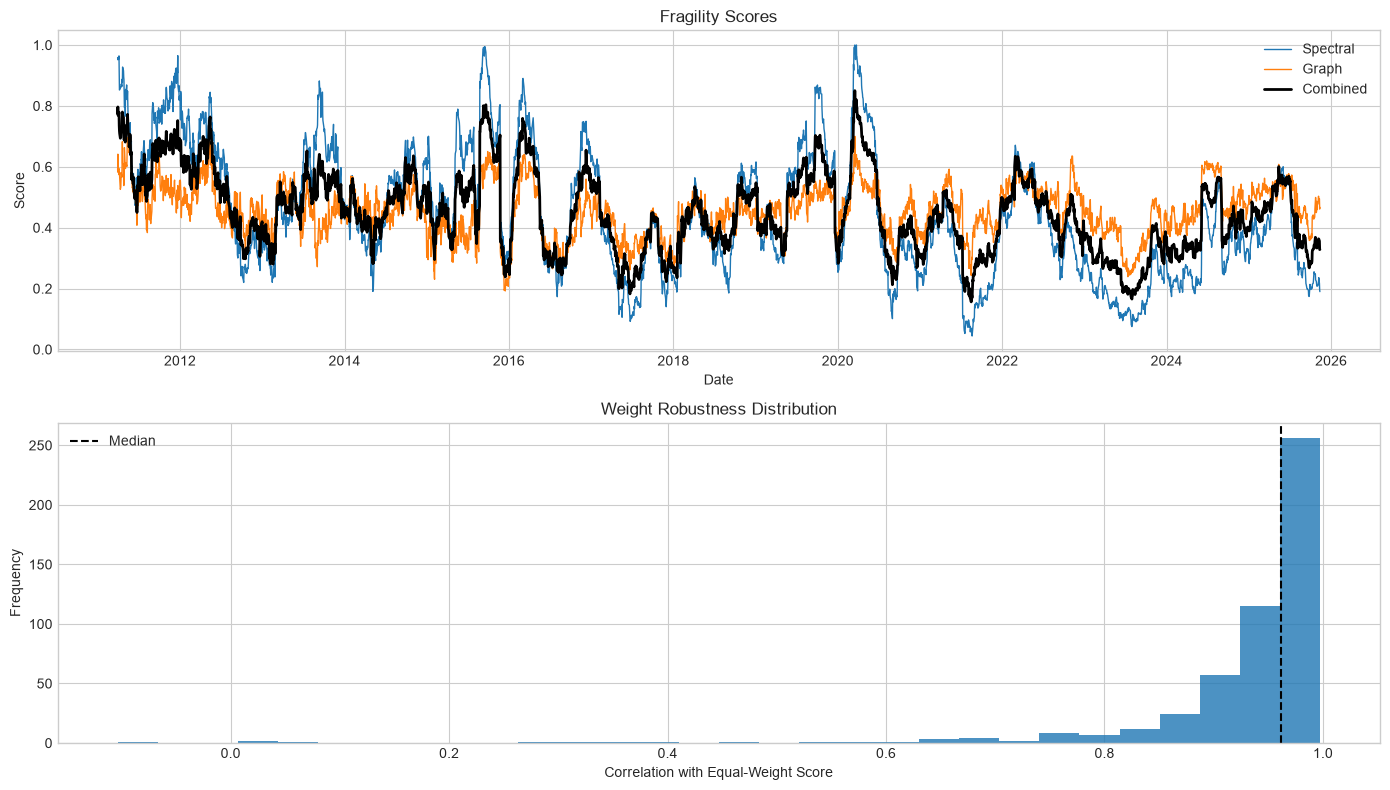

In [10]:
combined = pd.merge(
    spectral_df[['date', 'fragility_spectral', 'market_mode_norm', 'collapse_norm', 'avg_corr_norm', 'sync_norm']],
    graph_df[['date', 'fragility_graph', 'clustering_norm', 'centralization_norm', 'gcc_norm', 'inv_entropy_norm', 'inv_modularity_norm']],
    on='date',
    how='inner'
)

combined['fragility_total'] = combined[['fragility_spectral', 'fragility_graph']].mean(axis=1)

component_cols = [
    'market_mode_norm', 'collapse_norm', 'avg_corr_norm', 'sync_norm',
    'clustering_norm', 'centralization_norm', 'gcc_norm', 'inv_entropy_norm', 'inv_modularity_norm'
]

valid = combined.dropna(subset=component_cols + ['fragility_total']).copy()

# Weight robustness: compare equal-weight score to random simplex weights
X = valid[component_cols].values
eq_score = X.mean(axis=1)
rand_corr = []
for _ in range(500):
    w = np.random.dirichlet(np.ones(X.shape[1]))
    s = X @ w
    c = np.corrcoef(eq_score, s)[0, 1]
    if np.isfinite(c):
        rand_corr.append(c)

# Ablation: drop one component at a time
ablation = []
for c in component_cols:
    cols = [k for k in component_cols if k != c]
    s = valid[cols].mean(axis=1)
    ablation.append({
        'dropped_component': c,
        'corr_with_full': np.corrcoef(valid['fragility_total'], s)[0, 1],
        'mean_abs_diff': np.mean(np.abs(valid['fragility_total'] - s))
    })
ablation_df = pd.DataFrame(ablation).sort_values('corr_with_full', ascending=True)

print('Combined sample size:', len(combined))
print('Fragility total summary:')
print(combined['fragility_total'].describe())

print('Weight robustness (corr equal-weight vs random weights):')
print(pd.Series(rand_corr).describe(percentiles=[0.05, 0.5, 0.95]))

print('Ablation stability:')
print(ablation_df.to_string(index=False))

print('Component correlation matrix:')
print(valid[component_cols].corr().round(2))

fig, ax = plt.subplots(2, 1, figsize=(14, 8))
ax[0].plot(combined['date'], combined['fragility_spectral'], label='Spectral', lw=1.0)
ax[0].plot(combined['date'], combined['fragility_graph'], label='Graph', lw=1.0)
ax[0].plot(combined['date'], combined['fragility_total'], label='Combined', lw=2.0, color='black')
ax[0].set_title('Fragility Scores')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Score')
ax[0].legend()

ax[1].hist(rand_corr, bins=30, color='tab:blue', alpha=0.8)
if len(rand_corr) > 0:
    ax[1].axvline(np.median(rand_corr), color='black', ls='--', label='Median')
ax[1].set_title('Weight Robustness Distribution')
ax[1].set_xlabel('Correlation with Equal-Weight Score')
ax[1].set_ylabel('Frequency')
ax[1].legend()

plt.tight_layout()
plt.show()

## Methodology

The final market fragility score combines spectral and graph views with equal weighting:

$$F_t = rac{1}{2}eft(F_t^{spec} + F_t^{graph}
ight)$$

This avoids overfitting while preserving two complementary structures.

Robustness diagnostics:
- random-weight sensitivity: compare equal-weight score to 500 random convex combinations
- leave-one-component-out ablation
- component correlation matrix

These checks test whether conclusions depend on fragile weight choices or single features.

## Results and Analysis

Expected acceptance criteria for a robust score:
- high correlation between equal-weight and random-weight alternatives
- no single ablation drastically changes the score
- components are related but not perfectly redundant

If these conditions hold, the fragility series is stable, interpretable, and not an artifact of hand-picked coefficients.

Stress sample size: 42432 | Calm sample size: 42432 | Baseline sample size: 282672
Top structurally important stocks during stress:
                         stock  betweenness  closeness  eigenvector  composite_centrality  delta_composite_centrality                 sector
               ICICI Bank Ltd.     0.020926   0.420725     0.233880              0.225177                    0.034880                  Banks
                Axis Bank Ltd.     0.017804   0.411620     0.221777              0.217067                    0.046726                  Banks
           State Bank Of India     0.019446   0.410312     0.220680              0.216812                    0.000972                  Banks
          Larsen & Toubro Ltd.     0.026943   0.403202     0.193380              0.207842                    0.018995  Construction & Realty
               Tata Steel Ltd.     0.017183   0.392260     0.185989              0.198477                    0.003154      Mining & Minerals
                   Can

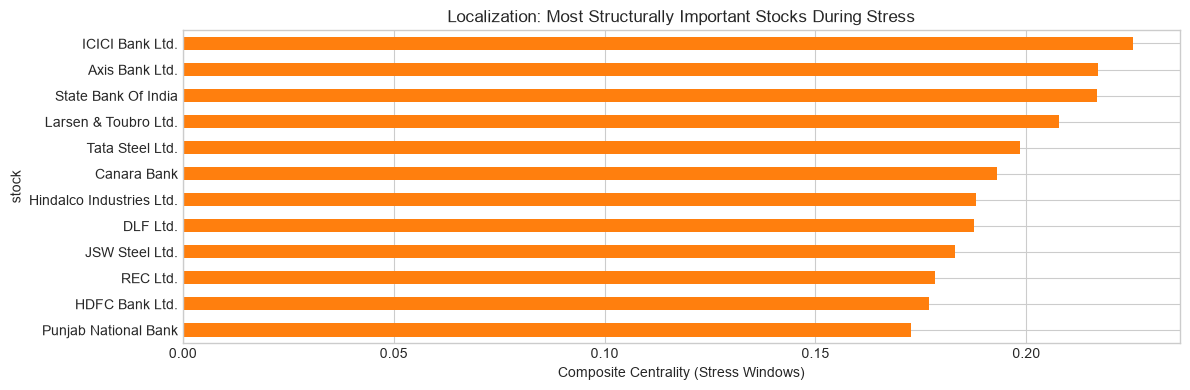

In [12]:
def graph_at_date(target_date, returns_df, window=60, mode='percentile', fixed_threshold=0.4, percentile=90):
    idx = returns_df.index.get_loc(target_date)
    X = returns_df.iloc[idx-window:idx]
    C_abs = X.corr().abs()
    G, thr, density = graph_from_corr_abs(C_abs, mode=mode, fixed_threshold=fixed_threshold, percentile=percentile)
    return G, thr, density

valid_total = combined.dropna(subset=['fragility_total']).copy()
q_hi = valid_total['fragility_total'].quantile(0.85)
q_lo = valid_total['fragility_total'].quantile(0.15)

stress_dates = valid_total.loc[valid_total['fragility_total'] >= q_hi, 'date']
calm_dates = valid_total.loc[valid_total['fragility_total'] <= q_lo, 'date']
all_dates = valid_total['date']

def avg_centralities(dates):
    rows = []
    for d in dates:
        d = pd.Timestamp(d)
        if d not in returns.index:
            continue
        i = returns.index.get_loc(d)
        if i < ROLL_WINDOW:
            continue

        G, thr, dens = graph_at_date(
            d, returns,
            window=ROLL_WINDOW,
            mode=GRAPH_THRESHOLD_MODE,
            fixed_threshold=GRAPH_FIXED_THRESHOLD,
            percentile=GRAPH_PERCENTILE
        )
        if G.number_of_edges() == 0:
            continue

        bet = nx.betweenness_centrality(G, weight='weight', normalized=True)
        clo = nx.closeness_centrality(G)

        try:
            eig = nx.eigenvector_centrality(G, max_iter=1000, tol=1e-6, weight='weight')
        except Exception:
            eig = nx.degree_centrality(G)

        for n in G.nodes():
            rows.append({
                'date': d,
                'stock': n,
                'betweenness': bet.get(n, np.nan),
                'closeness': clo.get(n, np.nan),
                'eigenvector': eig.get(n, np.nan)
            })

    out = pd.DataFrame(rows)
    if out.empty:
        return out
    out['composite_centrality'] = out[['betweenness', 'closeness', 'eigenvector']].mean(axis=1)
    return out

stress_cent = avg_centralities(stress_dates)
calm_cent = avg_centralities(calm_dates)
baseline_cent = avg_centralities(all_dates)

if stress_cent.empty or baseline_cent.empty:
    print('Localization warning: insufficient centrality data.')
    stock_rank = pd.DataFrame()
    sector_rank = pd.Series(dtype=float)
else:
    stress_avg = stress_cent.groupby('stock')[['betweenness', 'closeness', 'eigenvector', 'composite_centrality']].mean()
    baseline_avg = baseline_cent.groupby('stock')[['betweenness', 'closeness', 'eigenvector', 'composite_centrality']].mean()

    common = stress_avg.index.intersection(baseline_avg.index)
    delta = (stress_avg.loc[common] - baseline_avg.loc[common]).rename(columns=lambda c: f'delta_{c}')

    stock_rank = stress_avg.join(delta, how='left')
    stock_rank = stock_rank.join(stock_sector.rename('sector'), how='left')
    stock_rank = stock_rank.sort_values('composite_centrality', ascending=False)

    sector_rank = stock_rank.groupby('sector')['delta_composite_centrality'].mean().sort_values(ascending=False)

print('Stress sample size:', len(stress_cent), '| Calm sample size:', len(calm_cent), '| Baseline sample size:', len(baseline_cent))
print('Top structurally important stocks during stress:')
if not stock_rank.empty:
    cols = ['betweenness', 'closeness', 'eigenvector', 'composite_centrality', 'delta_composite_centrality', 'sector']
    print(stock_rank.head(15)[cols].reset_index().to_string(index=False))
else:
    print('No stock ranking available.')

print('Sectors with largest centrality uplift in stress (vs baseline):')
if len(sector_rank) > 0:
    print(sector_rank.head(10).to_string())
else:
    print('No sector ranking available.')

if not stock_rank.empty:
    plt.figure(figsize=(12, 4))
    plot_data = stock_rank.head(12)['composite_centrality'].iloc[::-1]
    plot_data.plot(kind='barh', color='tab:orange')
    plt.title('Localization: Most Structurally Important Stocks During Stress')
    plt.xlabel('Composite Centrality (Stress Windows)')
    plt.tight_layout()
    plt.show()

## Methodology

Localization module asks: which entities become structurally important when fragility is high?

Procedure:
- define stress and calm sets using top/bottom fragility quantiles
- build correlation graphs for each date
- compute interpretable centralities: betweenness, closeness, eigenvector
- compare average centrality in stress vs calm

The stress-minus-calm delta identifies load-bearing stocks and sectors.

## Results and Analysis

The ranked tables and bar chart identify names/sectors that become more central specifically during stressed regimes.

Interpretation:
- high positive delta implies stronger routing or influence role under stress
- sector aggregation shows where structural dependency concentrates

Limitation:
- centrality is inferred from correlation networks, so it reflects statistical dependency rather than causal fundamentals.

Contagion scenario date: 2020-03-17
Adaptive threshold used: 0.7247 | graph density: 0.1002
Seed stock: Hindalco Industries Ltd.
Average market stress path: [0.013 0.116 0.402 0.559 0.605 0.628 0.642 0.652 0.659]
First-hit ranking (which stocks are affected next):
                                            stock  final_stress  first_hit_step                   sector
       Adani Ports and Special Economic Zone Ltd.           1.0             2.0        Logistics & Ports
                                 Adani Power Ltd.           1.0             2.0                    Power
                              Ambuja Cements Ltd.           1.0             2.0   Construction Materials
                                   Axis Bank Ltd.           1.0             2.0                    Banks
                               Bajaj Finance Ltd.           1.0             2.0 NBFC's & Housing Finance
                               Bajaj Finserv Ltd.           1.0             2.0 NBFC's & Housing Finance


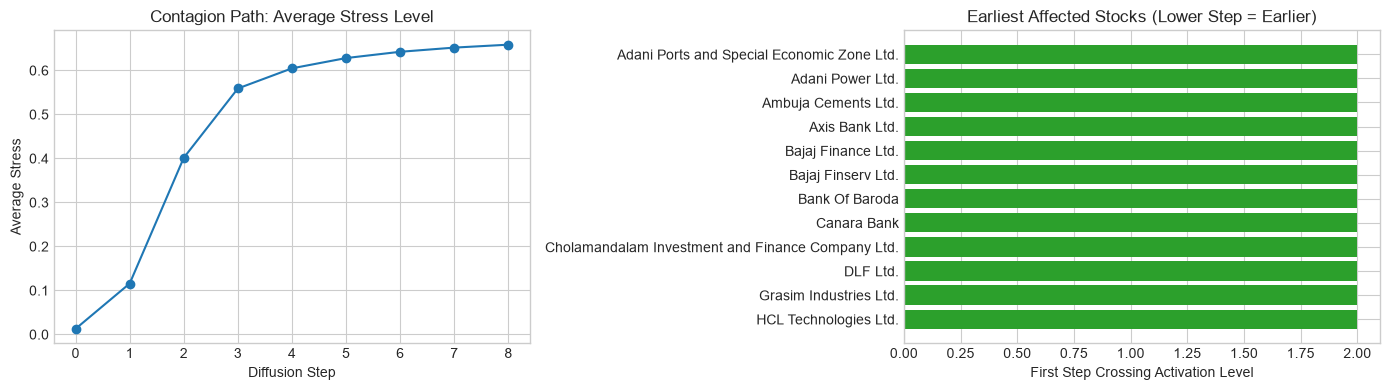

In [13]:
# Contagion module: deterministic diffusion on a stressed graph
peak_date = valid_total.nlargest(1, 'fragility_total')['date'].iloc[0]
G_peak, thr_peak, dens_peak = graph_at_date(
    peak_date,
    returns,
    window=ROLL_WINDOW,
    mode=GRAPH_THRESHOLD_MODE,
    fixed_threshold=GRAPH_FIXED_THRESHOLD,
    percentile=GRAPH_PERCENTILE
)

deg_weighted = dict(G_peak.degree(weight='weight'))
seed_stock = max(deg_weighted, key=deg_weighted.get)

nodes = list(G_peak.nodes())
idx_map = {n: i for i, n in enumerate(nodes)}
A = nx.to_numpy_array(G_peak, nodelist=nodes, weight='weight')
if A.max() > 0:
    A = A / A.max()

T_STEPS = 8
BETA = 0.25
ACTIVATION_LEVEL = 0.30

stress = np.zeros(len(nodes))
stress[idx_map[seed_stock]] = 1.0
history = [stress.copy()]

for _ in range(T_STEPS):
    inflow = A @ stress
    stress = np.clip(stress + BETA * (1 - stress) * inflow, 0, 1)
    history.append(stress.copy())

history = np.array(history)
avg_path = history.mean(axis=1)

first_hit_step = np.full(len(nodes), np.nan)
for i in range(len(nodes)):
    hits = np.where(history[:, i] >= ACTIVATION_LEVEL)[0]
    if len(hits) > 0:
        first_hit_step[i] = hits[0]

node_final = pd.DataFrame({
    'stock': nodes,
    'final_stress': history[-1],
    'first_hit_step': first_hit_step,
    'sector': [stock_sector.get(n, 'Unknown') for n in nodes]
})

node_next = node_final[node_final['stock'] != seed_stock].copy()
node_next = node_next.sort_values(['first_hit_step', 'final_stress'], ascending=[True, False])

sector_final = node_final.groupby('sector')['final_stress'].mean().sort_values(ascending=False)

print('Contagion scenario date:', peak_date.date())
print('Adaptive threshold used:', round(thr_peak, 4), '| graph density:', round(dens_peak, 4))
print('Seed stock:', seed_stock)
print('Average market stress path:', np.round(avg_path, 3))
print('First-hit ranking (which stocks are affected next):')
print(node_next.head(15).to_string(index=False))
print('Most affected sectors after diffusion:')
print(sector_final.head(10).to_string())

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(range(len(avg_path)), avg_path, marker='o')
ax[0].set_title('Contagion Path: Average Stress Level')
ax[0].set_xlabel('Diffusion Step')
ax[0].set_ylabel('Average Stress')

plot_next = node_next.dropna(subset=['first_hit_step']).head(12).iloc[::-1]
ax[1].barh(plot_next['stock'], plot_next['first_hit_step'], color='tab:green')
ax[1].set_title('Earliest Affected Stocks (Lower Step = Earlier)')
ax[1].set_xlabel('First Step Crossing Activation Level')

plt.tight_layout()
plt.show()

## Methodology

Contagion module answers: if one important node is stressed, who is affected next?

We use a deterministic diffusion model on the stressed-date correlation graph:
$$s^{(k+1)} = s^{(k)} + eta (1-s^{(k)}) A s^{(k)}$$

where:
- $s^{(k)} n [0,1]^N$ is node stress at step $k$
- $A$ is normalized weighted adjacency
- $eta$ controls propagation speed

Seed node is chosen as the highest weighted-degree stock in the peak-fragility graph for interpretability.

## Results and Analysis

Outputs provide:
- the stress date and seed stock
- market-wide stress trajectory across diffusion steps
- most exposed stocks/sectors at the end of propagation

Interpretation:
- faster path growth implies a tightly coupled market topology
- concentration of final stress in specific sectors indicates potential structural transmission channels

This module is intentionally simple and interpretable rather than predictive.

Detected change-point dates:
[datetime.date(2011, 6, 13), datetime.date(2015, 8, 26), datetime.date(2015, 11, 10), datetime.date(2016, 1, 22), datetime.date(2016, 4, 26), datetime.date(2016, 7, 5), datetime.date(2016, 9, 27), datetime.date(2017, 3, 1), datetime.date(2019, 11, 29), datetime.date(2020, 2, 10), datetime.date(2020, 5, 29), datetime.date(2020, 8, 7), datetime.date(2021, 6, 16), datetime.date(2022, 1, 4), datetime.date(2025, 7, 22)]
Regime segment summary:
 segment_id      start        end  mean_fragility  days     regime
          0 2011-03-30 2011-06-10        0.726148    50   Stressed
          1 2011-06-13 2015-08-25        0.507290  1045   Stressed
          2 2015-08-26 2015-11-09        0.682020    50   Stressed
          3 2015-11-10 2016-01-21        0.429891    50 Transition
          4 2016-01-22 2016-04-25        0.610488    60   Stressed
          5 2016-04-26 2016-07-04        0.476504    50 Transition
          6 2016-07-05 2016-09-26        0.292021    56    

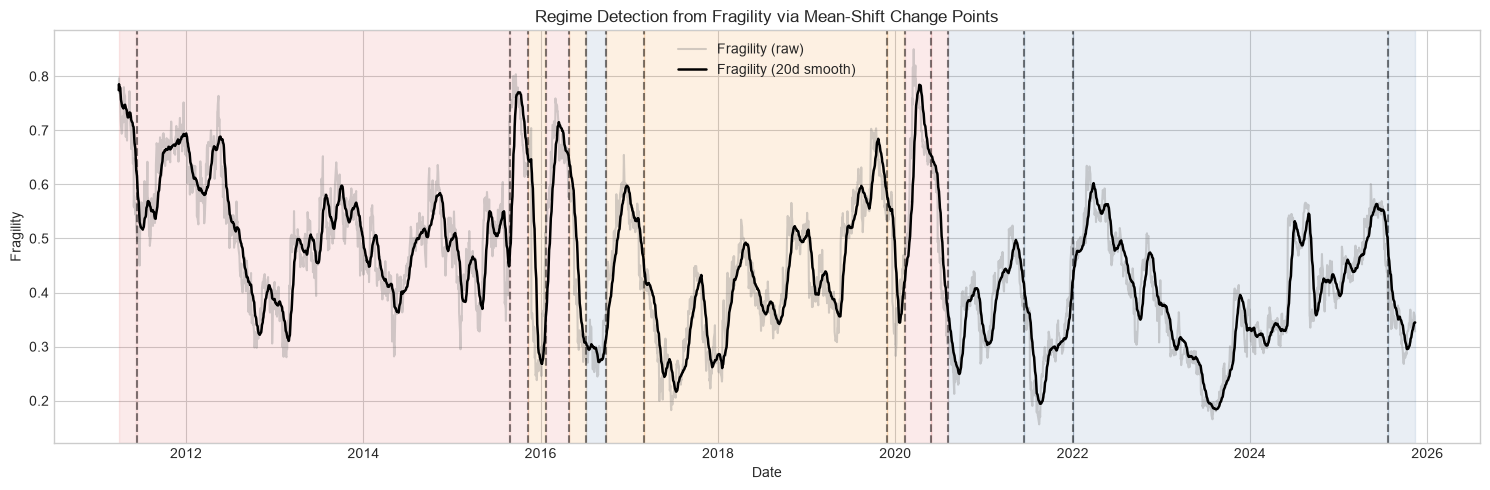

In [9]:
# Regime detection via simple mean-shift change-point heuristic
def detect_mean_shift_points(series: pd.Series, lookback: int = 50, threshold_std: float = 1.25, min_gap: int = 40):
    y = series.values
    n = len(y)
    scores = np.full(n, np.nan)

    for t in range(lookback, n - lookback):
        left = y[t-lookback:t]
        right = y[t:t+lookback]
        scores[t] = abs(np.mean(right) - np.mean(left))

    valid_scores = pd.Series(scores).dropna()
    if valid_scores.empty:
        return [], scores
    cutoff = valid_scores.mean() + threshold_std * valid_scores.std()

    candidates = np.where(scores >= cutoff)[0]
    cps = []
    for c in candidates:
        if (not cps) or (c - cps[-1] >= min_gap):
            cps.append(int(c))
    return cps, scores

reg = combined[['date', 'fragility_total']].dropna().copy().reset_index(drop=True)
reg['fragility_smooth'] = reg['fragility_total'].rolling(20, min_periods=1).mean()

cp_idx, cp_scores = detect_mean_shift_points(reg['fragility_smooth'], lookback=50, threshold_std=1.25, min_gap=50)
cp_dates = reg.loc[cp_idx, 'date'].tolist() if cp_idx else []

# Build segments
cuts = [0] + cp_idx + [len(reg)]
seg_id = np.zeros(len(reg), dtype=int)
for s in range(len(cuts)-1):
    seg_id[cuts[s]:cuts[s+1]] = s
reg['segment_id'] = seg_id

seg_mean = reg.groupby('segment_id')['fragility_smooth'].mean()
q1, q2 = seg_mean.quantile([0.33, 0.66]).values

def label_regime(v):
    if v <= q1:
        return 'Calm'
    if v <= q2:
        return 'Transition'
    return 'Stressed'

seg_label = seg_mean.apply(label_regime).to_dict()
reg['regime'] = reg['segment_id'].map(seg_label)

segment_table = reg.groupby('segment_id').agg(
    start=('date', 'min'),
    end=('date', 'max'),
    mean_fragility=('fragility_smooth', 'mean'),
    days=('date', 'count'),
    regime=('regime', 'first')
).reset_index()

print('Detected change-point dates:')
print([d.date() for d in cp_dates])
print('Regime segment summary:')
print(segment_table.to_string(index=False))

colors = {'Calm': '#4C78A8', 'Transition': '#F58518', 'Stressed': '#E45756'}

plt.figure(figsize=(15, 5))
plt.plot(reg['date'], reg['fragility_total'], color='gray', alpha=0.35, label='Fragility (raw)')
plt.plot(reg['date'], reg['fragility_smooth'], color='black', lw=1.8, label='Fragility (20d smooth)')

for sid, sub in reg.groupby('segment_id'):
    plt.axvspan(sub['date'].iloc[0], sub['date'].iloc[-1], color=colors[sub['regime'].iloc[0]], alpha=0.12)

for d in cp_dates:
    plt.axvline(d, ls='--', color='black', alpha=0.5)

plt.title('Regime Detection from Fragility via Mean-Shift Change Points')
plt.xlabel('Date')
plt.ylabel('Fragility')
plt.legend()
plt.tight_layout()
plt.show()

## Methodology

Regime module converts a continuous fragility signal into structural states.

We choose a simple change-point strategy instead of HMM:
- detect sustained mean shifts in smoothed fragility
- segment the timeline at detected change points
- label each segment by mean fragility terciles: Calm / Transition / Stressed

Reason for this choice:
- transparent assumptions
- easy auditability
- no latent-state estimation instability

This is adequate for structural regime mapping in an exploratory research notebook.

## Results and Analysis

The output provides change-point dates and a segment table with start/end, duration, average fragility, and regime label.

Interpretation:
- Stressed segments should align with known high-stress macro windows
- Transition segments capture structural movement between calm and stress

Limitation:
- regime boundaries depend on smoothing and threshold settings; sensitivity checks are advisable for production use.

# Final Research Summary

Methodological upgrades over the original notebook:
- removed look-ahead bias in normalization
- replaced single-day synchronization with rolling coherence
- replaced arbitrary weights with equal-weight baseline and robustness diagnostics
- replaced fixed graph-threshold dependence with adaptive percentile thresholding + sensitivity table
- added localization, contagion, and regime modules

The resulting fragility framework is simple, interpretable, and statistically valid for structural monitoring.